# Demonstration of tracker at large scale

While the main validation work is carried out using the 100-km images, we want to see the method in action on a larger scale. Ideally, we can look at data for all the regions in the paper. I've done an initial run on the Baffin Bay case. The segmentation was fast -- it took about 15 minutes to run for 1 month (April 2025). We'll look at those results first, then take a look at what is taking the tracker so long. (Perhaps the rotation calculation is the issue?) The main tracking calculation took 2 hours to run.

Baffin Bay results
* FSPipeline with LogLogQuadratic distance function, MinimumWeightMatching, and the default chained filter functions
* Mac Mini M4 with 24 GB memory
* Scene size 3500 by 6000 (about 750 km by 1500 km)
* Segmentation time: Approx 30 minutes
* Tracking time: Approx 90 minutes
* Another hour for the rotation computation

Odd results
* Some very high drift speeds ($>3$). Shouldn't that be impossible with the LogLogQuadratic Distance Threshold?
* Always missing lowest segment

In [1]:
import ultraplot as uplt
import skimage as ski
import pandas as pd
import numpy as np
import os


In [2]:
dataloc = "../../IceFloeTracker.jl/workflow/results/"

In [5]:
tracked = pd.read_csv(dataloc + 'baffin_bay-full.250m.2025-04-01.2025-05-01.FSPipeline.tracked.csv')

In [45]:
dt_seconds = np.array([x.replace(' milliseconds', '') for x in tracked['Δt'].fillna('NaN')]).astype(float) / 1e3
tracked['dt_seconds'] = dt_seconds
tracked['dx_meters'] = tracked['Δx']
tracked['speed'] = tracked['dx_meters'] / tracked['dt_seconds']

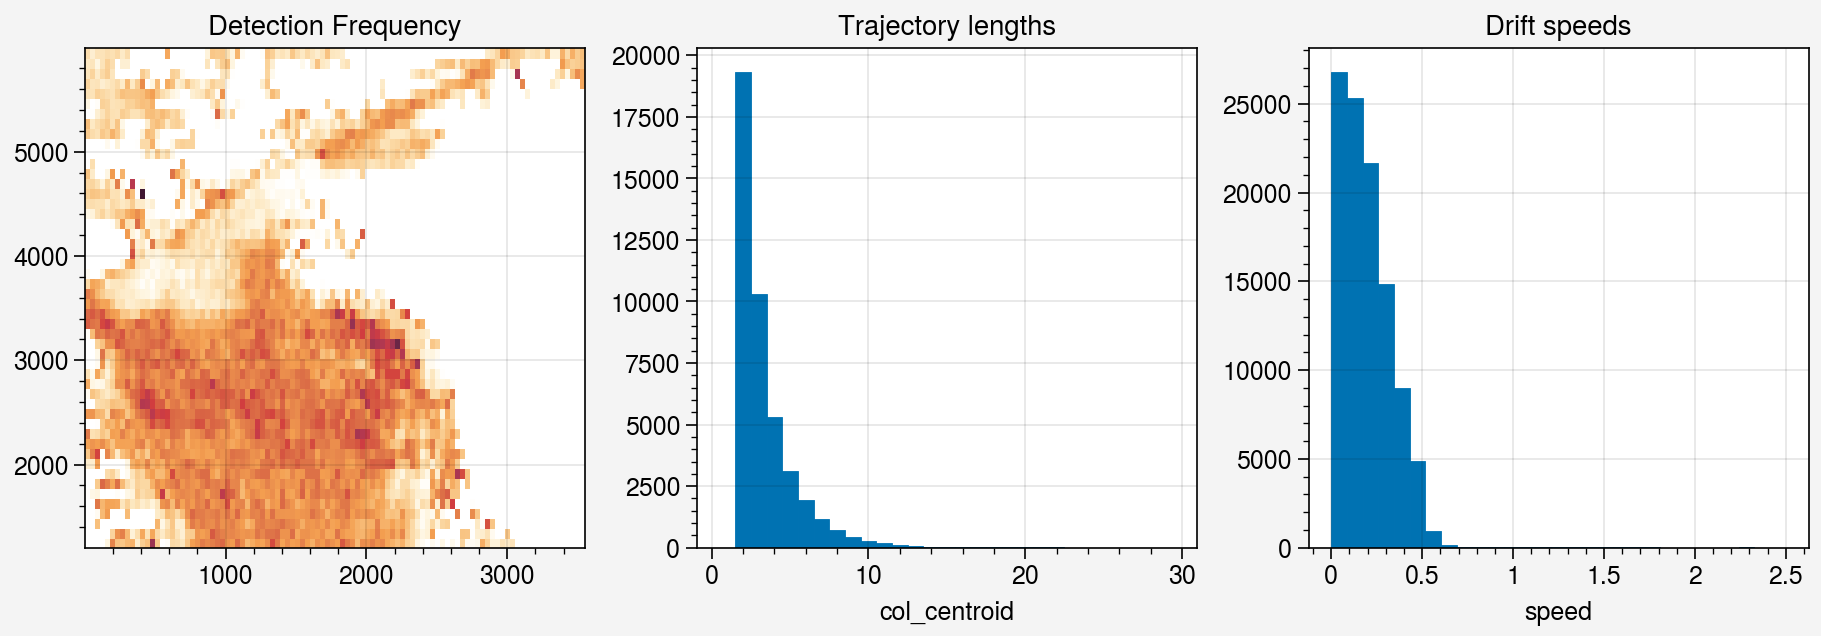

In [46]:
fig, axs = uplt.subplots(ncols=3, sharey=False, sharex=False)
ax = axs[0]
_ = ax.hist2d(tracked.col_centroid, 6000 - tracked.row_centroid, bins=[100, 50])
ax.format(title='Detection Frequency')

ax = axs[1]
ax.hist(tracked.groupby("ID").count()['col_centroid'], bins=np.arange(0.5, 30.5))
ax.format(title='Trajectory lengths')

ax = axs[2]
ax.hist(tracked['speed'], bins=np.linspace(0, 2.5, 30))
ax.format(title='Drift speeds')

In [60]:
landmask = ski.io.imread(dataloc + 'baffin_bay-full/250m.2025.landmask.tiff')

In [64]:
long_tracks = tracked.groupby("ID").filter(lambda x: len(x) > 5)

In [55]:
long_tracks.groupby("ID").area.mean()

ID
42        253.416667
79       1211.333333
112       152.166667
127       302.454545
226       234.384615
            ...     
42801     277.130435
42894     112.000000
43029     516.666667
43074     104.727273
43104     180.642857
Name: area, Length: 601, dtype: float64

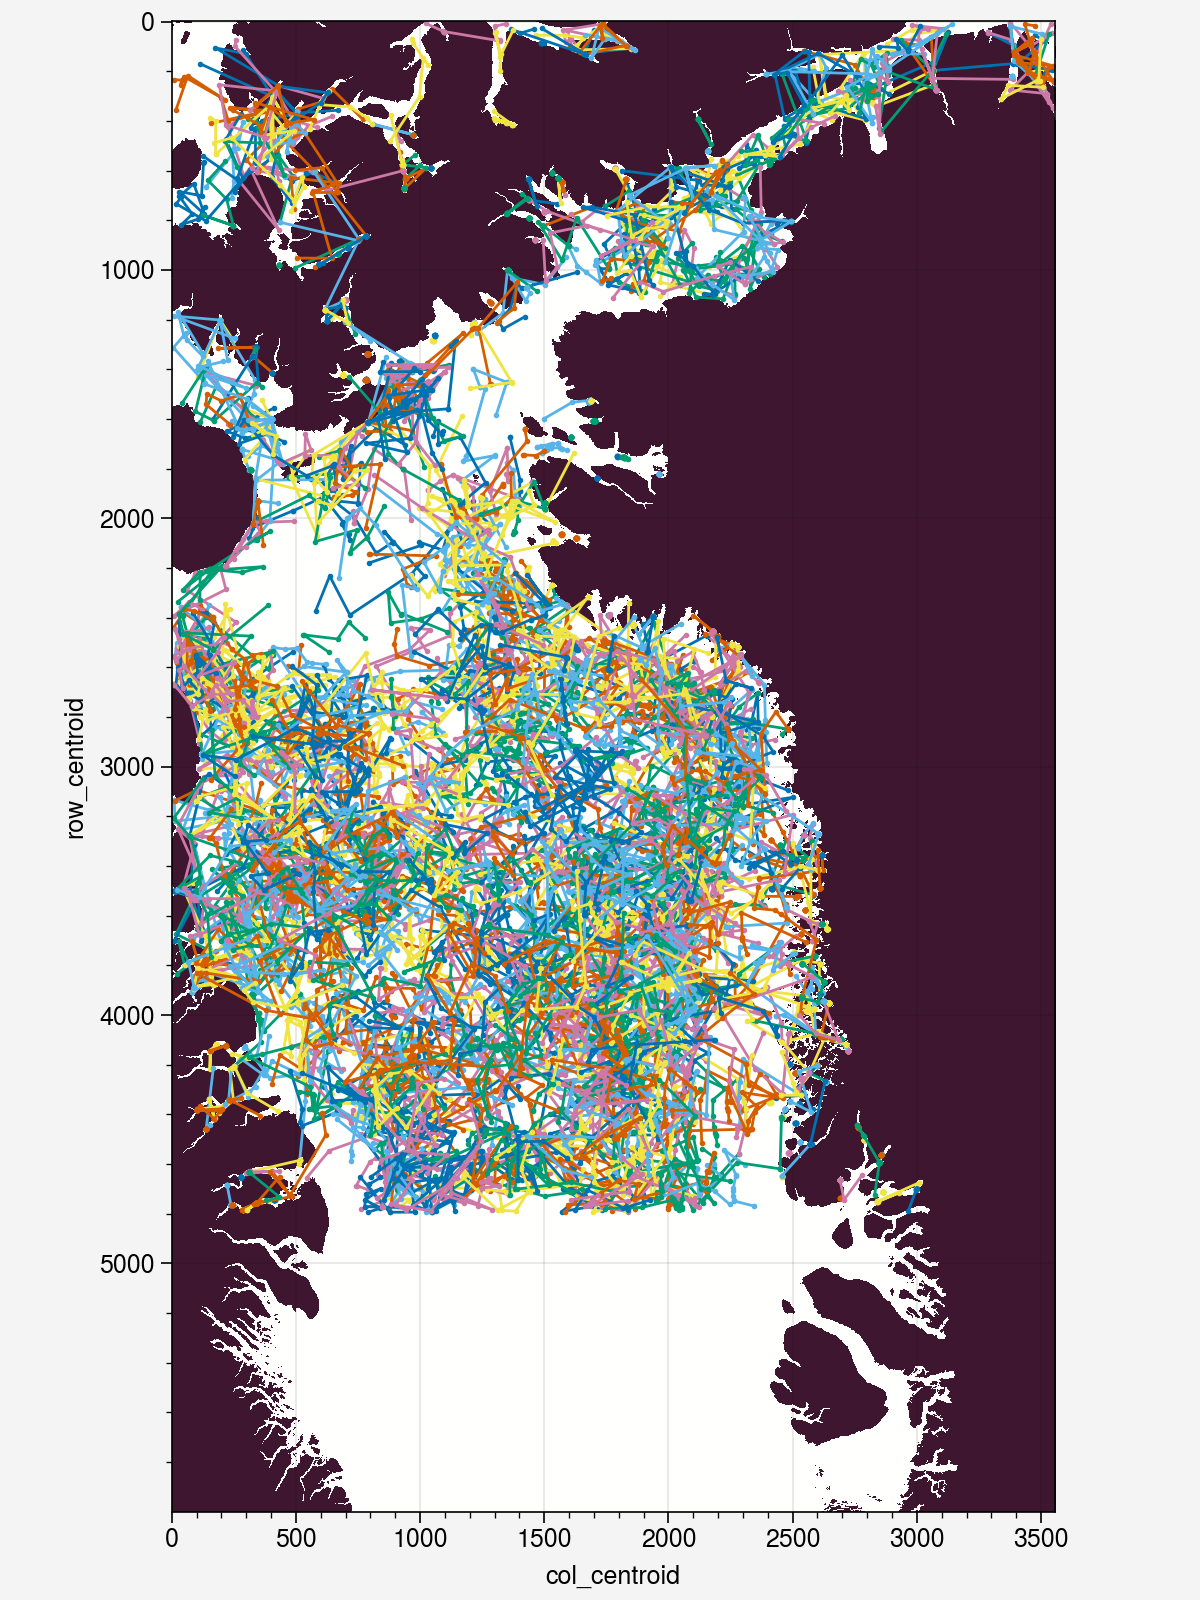

In [68]:
fig, ax = uplt.subplots(width=6, height=8)
ax.imshow(landmask)
for name, group in long_tracks.groupby("ID"):
    size = np.mean(group.area) # size in pixels
    speed = np.max(group.speed) 
    if size > 300:
        if speed < 1.5:
              ax.plot(group.col_centroid, group.row_centroid, m='.', ms=2, lw=1)
# ax.scatter(long_tracks.col_centroid, 6000 - long_tracks.row_centroid, ms=1)

ax.format(xreverse = False)

In [ ]:
# Without cleanup - what are the drift speeds?

In [79]:
import rasterio as rio
ref_img = rio.open(dataloc + 'baffin_bay-full.250m.2025-04-01.aqua/falsecolor.tiff')
left, bottom, right, top = ref_img.bounds

In [80]:
tracked['datetime'] = pd.to_datetime(tracked['passtime'])
x, y = ref_img.xy(tracked.row_centroid, tracked.col_centroid)
tracked['x_stere'] = x
tracked['y_stere'] = y

In [89]:
# Slow method, but need to do it individually
for name, group in tracked.groupby('ID'):
    tracked.loc[group.index, 'u'] = (group['x_stere'] - group['x_stere'].shift(1)) / group['dt_seconds']
    tracked.loc[group.index, 'v'] = (group['y_stere'] - group['y_stere'].shift(1)) / group['dt_seconds']

In [87]:
np.sqrt(u**2 + v**2)

0         NaN
1    0.368523
dtype: float64

In [88]:
group.speed

0         NaN
1    0.368523
Name: speed, dtype: float64

In [132]:
import pyproj
import scipy.stats as stats

##### Calculate Velocity Mean and Comparison with NSIDC ######
min_x = left
max_x = right
min_y = bottom
max_y = top

x_bins = np.arange(min_x, max_x, 25e3)
y_bins = np.arange(min_y, max_y, 25e3)
xc = 0.5*(x_bins[1:] + x_bins[:-1])
yc = 0.5*(y_bins[1:] + y_bins[:-1])
X, Y = np.meshgrid(xc, yc)

# Select data from 25 km bins for IFT and for NSIDC to compute monthly means
crs0 = pyproj.CRS('WGS84')
crs1 = pyproj.CRS('epsg:3413')
transformer_pstere = pyproj.Transformer.from_crs(crs1, crs_to=crs0, always_xy=True)

lon_grid, lat_grid = transformer_pstere.transform(np.ravel(X), np.ravel(Y))
lon_grid = np.reshape(lon_grid, X.shape)
lat_grid = np.reshape(lat_grid, Y.shape)

u_data = {}
v_data = {}
hist = {}
diffs_mean = {}
diffs_u = {}
diffs_v = {}

for month in [4]:
    u_data[month] = {}
    v_data[month] = {}
    hist[month] = {}
    for label, suffix in zip(['IFT'], ['']):
        sel = (tracked.datetime.dt.month == month) & (tracked['speed'] < 1.5) & (tracked['area'] > 400)
        x = tracked.x_stere
        y = tracked.y_stere
        u = tracked['u' + suffix] * 100
        v = tracked['v' + suffix] * 100
        
        hist2d = np.histogram2d(
            tracked.loc[sel, :].dropna(subset=['u'], axis=0)['x_stere'], 
            tracked.loc[sel, :].dropna(subset=['v'], axis=0)['y_stere'],
            bins=[x_bins, y_bins])
        
        df_hist = pd.DataFrame(hist2d[0], index=xc, columns=yc)
        hist[month] = df_hist
        
        u_mean, xedges, yedges, binnumber = stats.binned_statistic_2d(
            x[sel], y[sel], values=u[sel], statistic='mean', 
            bins=[x_bins, y_bins])
        v_mean, xedges, yedges, binnumber = stats.binned_statistic_2d(
            x[sel], y[sel], values=v[sel], statistic='mean', 
            bins=[x_bins, y_bins])

        # # Rotation from Earth coordinates to the north polar stereographic grid for display
        U_nps = u_mean.T * np.sin(np.deg2rad(lon_grid + 45)) + v_mean.T * np.cos(np.deg2rad(lon_grid + 45))
        V_nps = v_mean.T * np.cos(np.deg2rad(lon_grid + 45)) - u_mean.T * np.sin(np.deg2rad(lon_grid + 45))
        u_data[month][label] = pd.DataFrame(U_nps.T, index=xc, columns=yc)
        v_data[month][label] = pd.DataFrame(V_nps.T, index=xc, columns=yc)


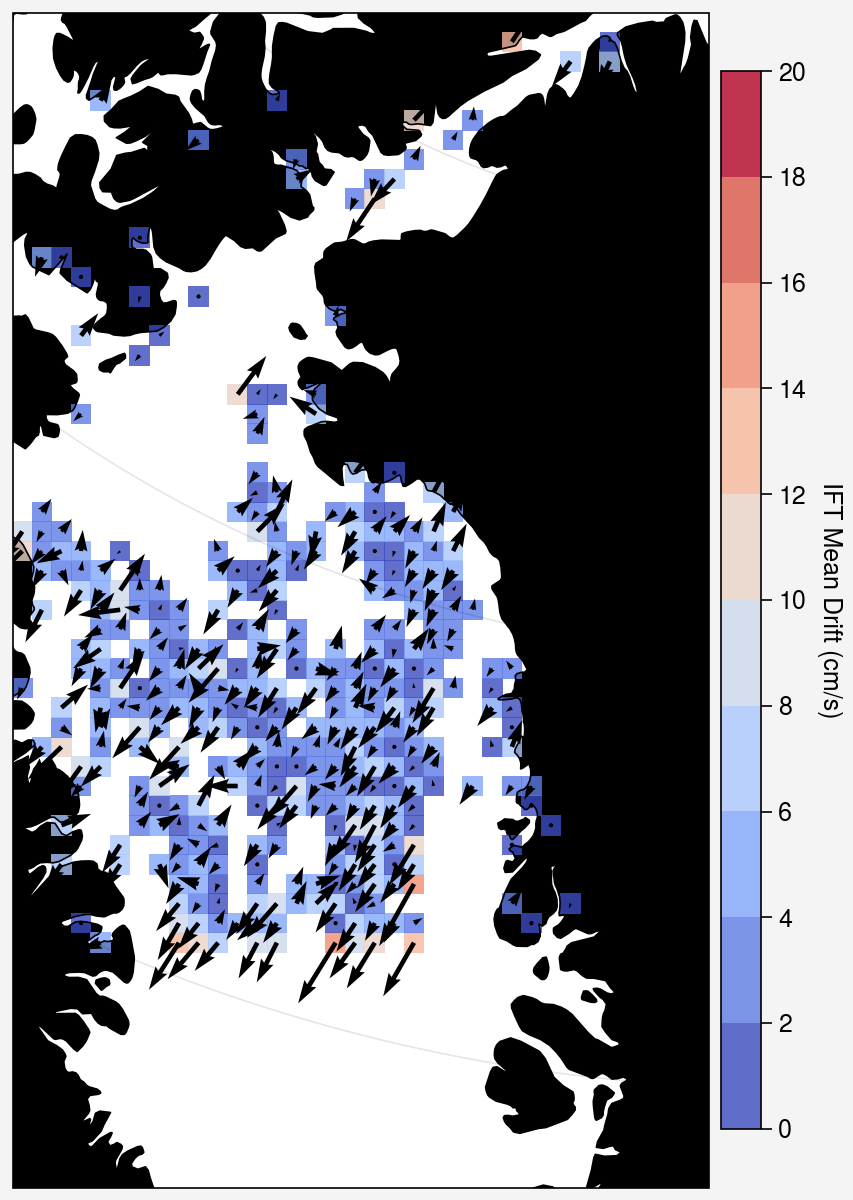

In [133]:
import cartopy.crs as ccrs
uplt.rc['reso'] = 'med'
uplt.rc['geo.round'] = False
xspacing = 1
yspacing = 1
crs = ccrs.NorthPolarStereo(central_longitude=-45, true_scale_latitude=70)
fig, ax = uplt.subplots(height=6, proj='npstere',
                         proj_kw={'lon_0': -45}, ncols=1, nrows=1, share=False)
ax.set_extent([left, right, bottom, top], crs=crs)  
ax.format(land=True, coast=True, lonlocator=np.arange(-30, 30, 10),
          latmax=85, latlocator=np.arange(55, 85, 5), 
       landzorder=0, landcolor='k', facecolor='w')

idx_data = hist[month] > 30
speed = np.sqrt(u_data[month]['IFT'] **2 + v_data[month]['IFT'] **2)
c1 = ax.pcolor(lon_grid, lat_grid, speed.where(idx_data).T.values, vmin=0, vmax=20,
       transform=ccrs.PlateCarree(), cmap='coolwarm', alpha=0.8)

ax.quiver(lon_grid[::xspacing, ::yspacing], lat_grid[::xspacing, ::yspacing],
          u_data[month]['IFT'].where(idx_data).T.values[::xspacing, ::yspacing],
          v_data[month]['IFT'].where(idx_data).T.values[::xspacing, ::yspacing],
       transform=ccrs.PlateCarree(), color='k', scale=150, width=1/150)
ax.colorbar(c1, label='IFT Mean Drift (cm/s)', loc='r', shrink=0.9)

Experiment results
* Noisy drift field needs to be addressed
* Reducing shapes which intersect the boundaries will likely improve processing speed
* Post-segmentation cleanup required
  * Clearing intersection with land mask would reduce a ton of false positives
* Drift field does not appear particularly coherent
* Mysterious lack of data from lower tiles. Investigate the cloud masks and the ice masks

# Checking the cloud and ice maps

In [156]:

ice_mask = ski.io.imread(dataloc + 'baffin_bay-full.250m.2025-04-02.aqua/FSPipeline/ice_mask.tiff')
cloud_mask = ski.io.imread(dataloc + 'baffin_bay-full.250m.2025-04-02.aqua/FSPipeline/cloud_mask.tiff')
label_mask = ski.io.imread(dataloc + 'baffin_bay-full.250m.2025-04-02.aqua/FSPipeline/labels_map.tiff')

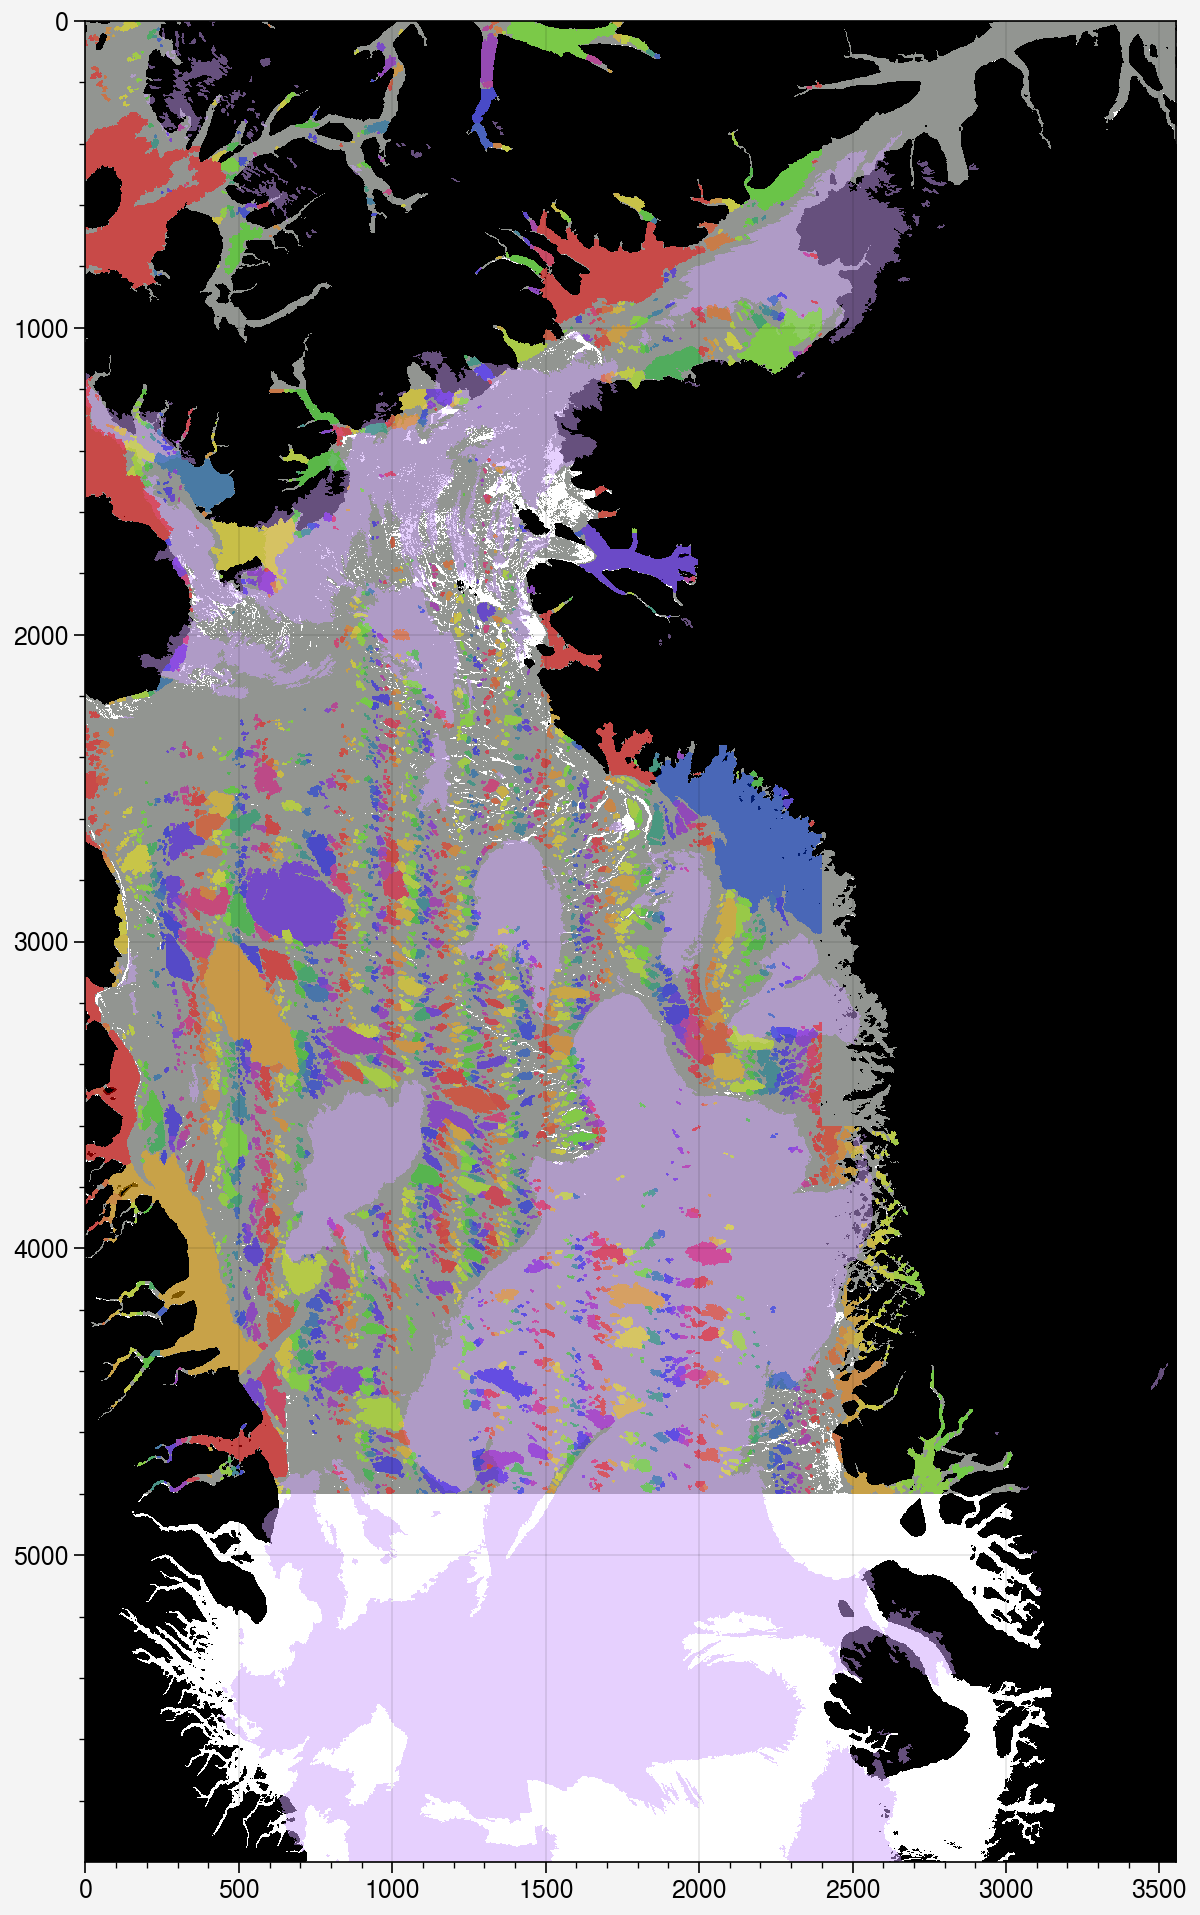

In [159]:
fig, ax = uplt.subplots(width=6)
ax.imshow(np.ma.masked_array(landmask, landmask==0), color='k')
ax.imshow(np.ma.masked_array(ice_mask, ice_mask==0), color='gray')
ax.imshow(np.ma.masked_array(cloud_mask, cloud_mask==0), color='lilac', alpha=0.5)
ax.imshow(np.ma.masked_array(label_mask, label_mask==0), cmap='prism', alpha=0.5)
fig.save('../figures/test_img_baffin`.png', dpi=300)

* cloud mask alignment with land mask looks wrong (wasn't getting cleared)
* tiling -- either filter or tile generation is wrong